## Correlation Analysis with Financial Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import yfinance as yf

In [8]:
stock1 = 'WTI' # Crude oil
stock2 = 'DAL' # Delta Airlines

df = yf.download([stock1, stock2], period='max')
# df = df.droplevel(1, axis=1)
df.head()

/tmp/ipykernel_5917/297248323.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download([stock1, stock2], period='max')
[*********************100%***********************]  2 of 2 completed


Price      Close            High            Low            Open             \
Ticker       DAL        WTI  DAL        WTI DAL        WTI  DAL        WTI   
Date                                                                         
2005-01-28   NaN  13.292426  NaN  14.226488 NaN  13.292426  NaN  14.010936   
2005-01-31   NaN  13.076876  NaN  13.357094 NaN  12.573918  NaN  13.292428   
2005-02-01   NaN  13.084062  NaN  13.220579 NaN  12.990656  NaN  13.076878   
2005-02-02   NaN  13.084062  NaN  13.220579 NaN  13.069692  NaN  13.112803   
2005-02-03   NaN  13.112795  NaN  13.184646 NaN  13.098424  NaN  13.112795   

Price      Volume           
Ticker        DAL      WTI  
Date                        
2005-01-28    NaN  9813500  
2005-01-31    NaN  1776800  
2005-02-01    NaN   656500  
2005-02-02    NaN   265300  
2005-02-03    NaN   303200

In [10]:
df.tail()

Price           Close             High              Low             Open  \
Ticker            DAL   WTI        DAL   WTI        DAL   WTI        DAL   
Date                                                                       
2026-05-04  68.500000  4.38  70.389999  4.40  67.870003  4.14  68.669998   
2026-05-05  70.860001  4.21  71.330002  4.34  68.910004  4.10  68.930000   
2026-05-06  73.339996  3.82  74.750000  3.93  72.730003  3.79  74.379997   
2026-05-07  73.110001  3.82  74.970001  3.82  72.300003  3.57  74.239998   
2026-05-08  73.330002  3.71  73.930000  3.75  72.699997  3.40  73.430000   

Price                Volume           
Ticker       WTI        DAL      WTI  
Date                                  
2026-05-04  4.28  8584400.0  6932200  
2026-05-05  4.28  8247000.0  4888600  
2026-05-06  3.83  9503800.0  7264800  
2026-05-07  3.67  8301300.0  5526400  
2026-05-08  3.65  5071000.0  8357900

In [11]:
df = df.dropna()

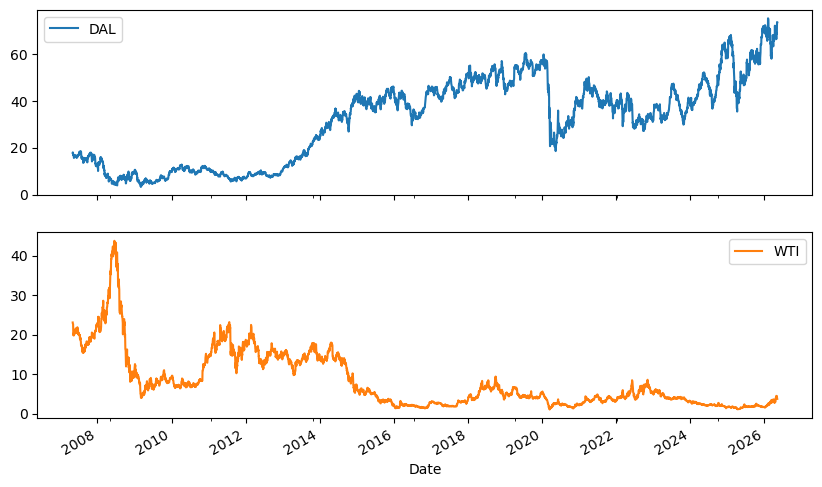

In [12]:
df['Close'].plot(subplots=True, figsize=(10,6));

In [13]:
df = df['Close']
df

Ticker,DAL,WTI
Date,,
2007-05-03,17.856087,23.085932
2007-05-04,18.080145,22.846962
2007-05-07,17.545834,22.665920
2007-05-08,16.916740,20.276228
2007-05-09,17.054628,20.138639
...,...,...
2026-05-04,68.500000,4.380000
2026-05-05,70.860001,4.210000
2026-05-06,73.339996,3.820000


<Axes: xlabel='Date'>

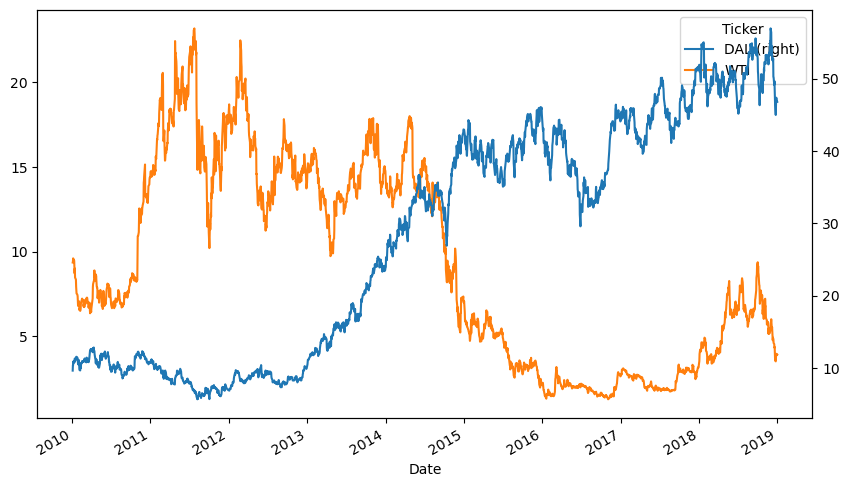

In [19]:
df.loc['2010':'2018'].plot(secondary_y=stock2, figsize=(10,6))

In [17]:
df.index

DatetimeIndex(['2007-05-03', '2007-05-04', '2007-05-07', '2007-05-08',
               '2007-05-09', '2007-05-10', '2007-05-11', '2007-05-14',
               '2007-05-15', '2007-05-16',
               ...
               '2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30',
               '2026-05-01', '2026-05-04', '2026-05-05', '2026-05-06',
               '2026-05-07', '2026-05-08'],
              dtype='datetime64[ns]', name='Date', length=4785, freq=None)

In [20]:
df_sm = df.loc['2010': '2019']

In [21]:
df_sm

Ticker,DAL,WTI
Date,,
2010-01-04,9.669173,9.360462
2010-01-05,10.427541,9.421542
2010-01-06,10.436152,9.604782
2010-01-07,10.935987,9.505526
2010-01-08,10.746396,9.543701
...,...,...
2019-12-24,57.224922,5.316233
2019-12-26,57.388729,5.392451
2019-12-27,56.926224,5.135214


In [22]:
rets = np.log(df_sm/df_sm.shift(1))

In [23]:
rets.dropna(inplace=True)

In [24]:
rets

Ticker,DAL,WTI
Date,,
2010-01-05,0.075508,0.006504
2010-01-06,0.000826,0.019262
2010-01-07,0.046783,-0.010388
2010-01-08,-0.017488,0.004008
2010-01-11,0.025338,-0.008032
...,...,...
2019-12-24,-0.000842,0.018084
2019-12-26,0.002858,0.014235
2019-12-27,-0.008092,-0.048878


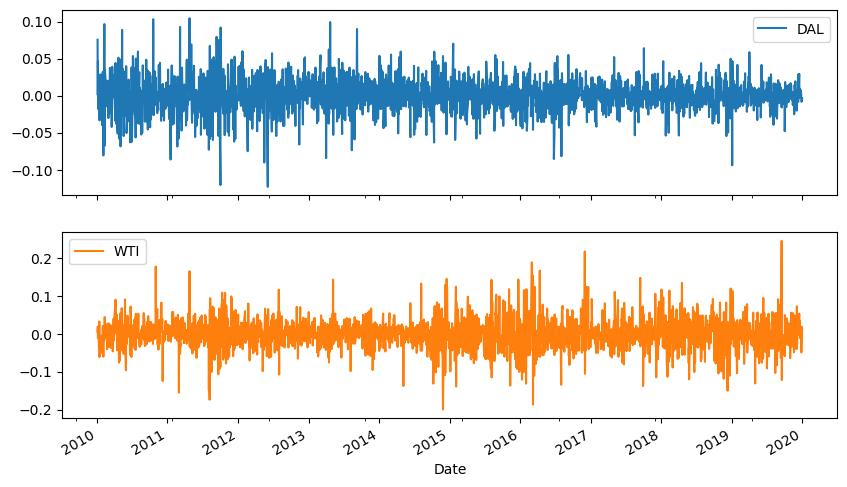

In [26]:
rets.plot(subplots=True, figsize=(10,6));

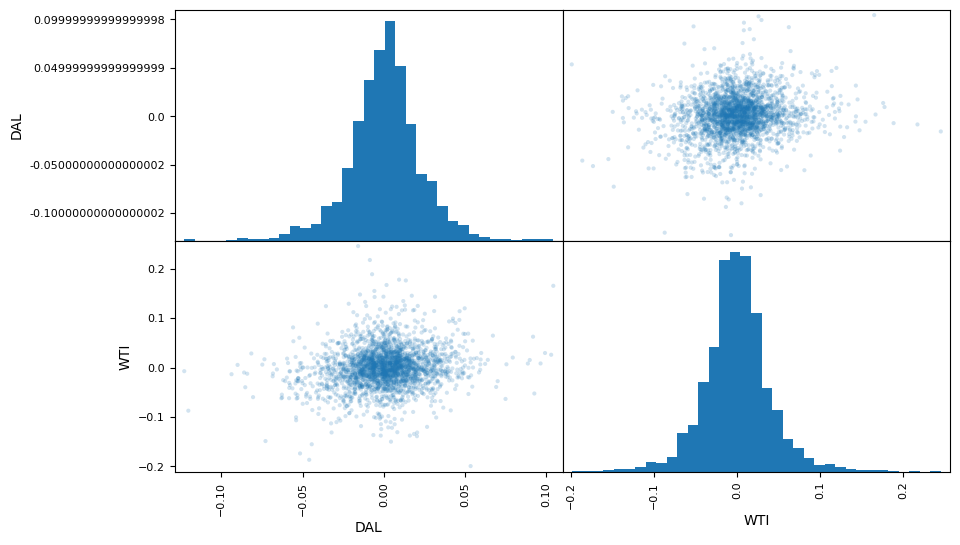

In [27]:
pd.plotting.scatter_matrix(rets,
                          alpha=0.2,
                          diagonal='hist',
                          hist_kwds={'bins':35},
                          figsize=(10,6));

#### OLS Regression

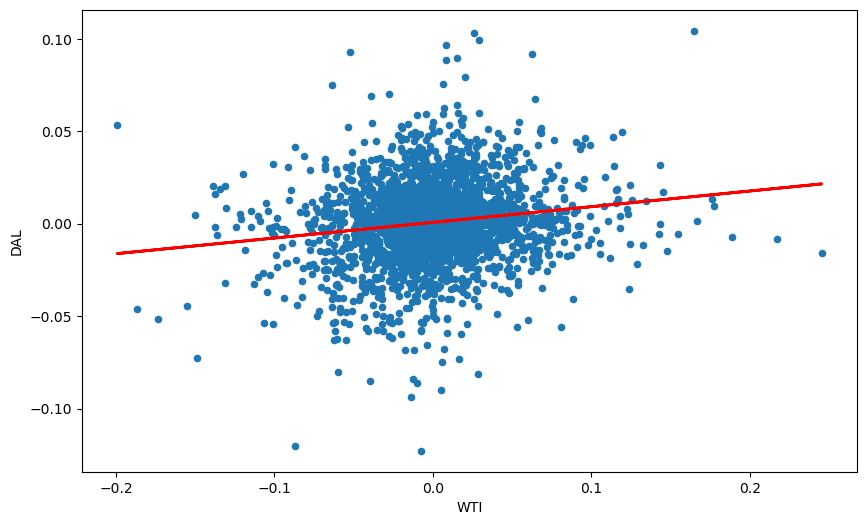

In [29]:
reg = np.polyfit(rets[stock1], rets[stock2], deg=1)

ax = rets.plot(kind='scatter', x=stock1, y=stock2, figsize=(10,6))
ax.plot(rets[stock1], np.polyval(reg, rets[stock1]), color='red', lw=2);

#### Correlation

In [30]:
rets.corr()

Ticker,DAL,WTI
Ticker,,
DAL,1.000000,0.154264
WTI,0.154264,1.000000


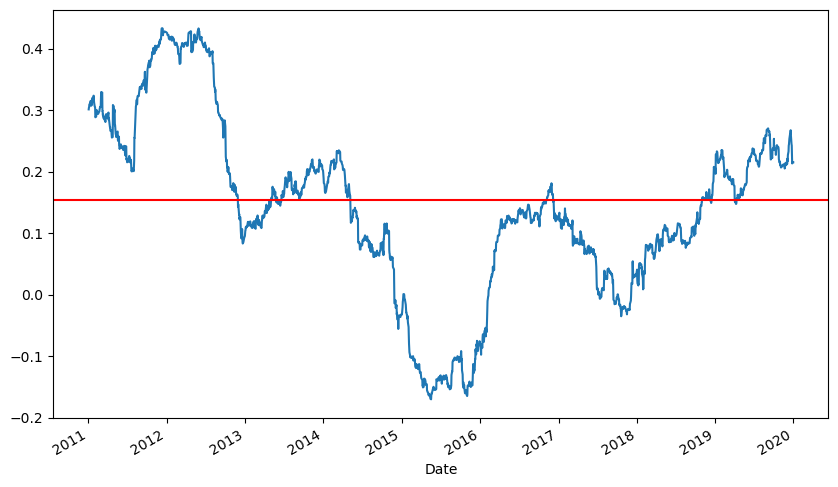

In [31]:
ax = rets[stock1].rolling(window=252).corr(rets[stock2]).plot(figsize=(10,6))
ax.axhline(rets.corr().iloc[0,1], c='r');